# 03 — Exploratory Data Analysis & Dimensionality Reduction

**Purpose:** Comprehensive exploration of the cleaned Steam games dataset to inform ML model development in Phase 4.

**Data source:** `cleaned_games` table from `steam.db`, created by `02_data_cleaning.ipynb`.

**Analysis goals:**
1. Understand the distribution and relationships of key features
2. Apply dimensionality reduction (PCA) to understand feature structure
3. Validate target variable construction (regression & classification)
4. Identify multicollinearity and recommend feature engineering strategies
5. Provide actionable insights for Phase 4 model development

**Key outputs:**
- PCA analysis with component interpretation
- Distribution analysis of numerical and categorical features
- Target variable validation (current_price, value_retention_tier)
- Correlation analysis and multicollinearity detection
- Feature importance rankings
- Recommendations for preprocessing and model selection

## Methodology Notes

**Feature set in this notebook mirrors the modeling notebooks (04, 04c, 05).**

### Continuous numeric features (8)
- `days_since_release`, `release_year`, `release_month`
- `initial_price` (USD, ITAD-derived) + `log_initial_price`
- `review_score` (positive ratio)
- `log_total_reviews` (raw `total_reviews` is heavy-tailed: median 28, max 9.5M)
- `log_ownership` (SteamSpy band midpoint)
- `log_achievements_total` (raw is capped at 5,000 by Steam's API for achievement-farm games)

### Categorical features (4)
- `primary_genre` (Steam's first listed genre)
- `is_multiplayer`, `has_controller_support` (binary, derived from Steam categories)
- `player_engagement` (Low / Medium / High by 100, 1000 player thresholds)

### High-cardinality (1)
- `publisher` -- target-encoded in modeling, here just descriptive

### Target
- **Continuous**: `max_discount_ever / 100` -- 0 to 1, the deepest discount each game has reached. This is what notebook 04 Step 4.4 regresses.
- **Discrete (for narrative only)**: quartile bins of the same target -- shown later in this notebook for readability, but not the actual model target.

### Removed during the cleaning audit (gone from `cleaned_games`):
- `developer_tier` -- the AAA hand-list had ~18% substring false positives, and the Indie branch was unreachable (SteamSpy floor was 200k owners). Replaced by `publisher` target-encoding in the model.
- `value_retention_tier` -- the 0.85 / 0.50 / 0.25 boundaries were hand-picked; the `Premium Hold` definition (`ever_discounted == 0`) conflicted with the modeling filter that requires `max_discount_ever > 0`. Replaced by direct discount-depth modeling.
- `price_tier` (kept on `cleaned_games` for narrative) -- model uses continuous `initial_price` instead.
- `discount_depth` (game-level, single-snapshot) -- redundant with `max_discount_ever`.
- `owners` and `price_retention` -- aliases of `ownership_midpoint` and `price_retention_ratio`; dropped to declutter.

### Notebook 04 changes reflected here
- Log-transformed numerics persist on `cleaned_games`, so EDA reads them directly.
- Filter funnel matches Step 4.2 exactly (publisher, release_month, primary_genre, etc. must all be non-null).


## Setup

In [1]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

import warnings
warnings.filterwarnings('ignore')

# Bootstrap: make src importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# Color palettes (matching project style)
PALETTE = sns.color_palette('husl', 10)
TIER_COLORS = {
    'Premium Hold': '#2ecc71',
    'Standard Depreciation': '#3498db',
    'Heavy Discount': '#f39c12',
    'Permanent Bargain': '#e74c3c'
}

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Find and connect to database
# Try multiple possible locations
possible_paths = [
    PROJECT_ROOT / 'data' / 'steam.db',  # Standard project structure
    PROJECT_ROOT / 'data' / 'steam 1.db',  # Alternative name
    Path('steam 1.db'),  # Current directory
    Path('steam.db'),  # Current directory alternative
    Path('../data/steam.db'),  # Up one level
    Path('data/steam.db'),  # Subdirectory
]

db_path = None
for path in possible_paths:
    if path.exists():
        db_path = path
        break

if db_path is None:
    raise FileNotFoundError(
        f"Database file not found. Searched in:\n" +
        "\n".join(f"  - {p}" for p in possible_paths) +
        "\n\nRun 01_data_collection.ipynb and 02_data_cleaning.ipynb first."
    )

print(f"Found database: {db_path}")
conn = sqlite3.connect(db_path)

# Check available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    conn
)['name'].tolist()

print(f"Tables ({len(tables)}): {tables}")

if 'cleaned_games' not in tables:
    raise ValueError(
        "Table 'cleaned_games' not found in database.\n"
        "Please run 02_data_cleaning.ipynb first to create this table."
    )

Found database: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\data\steam.db
Tables (14): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']


In [3]:
# Load cleaned data
df = pd.read_sql_query('SELECT * FROM cleaned_games', conn)
print(f'Loaded {len(df):,} games from cleaned_games')
print(f'Features: {len(df.columns)}')
print(f'\nColumns: {list(df.columns)}')

Loaded 4,924 games from cleaned_games
Features: 32

Columns: ['appid', 'title', 'developer', 'publisher', 'release_date', 'days_since_release', 'release_year', 'release_month', 'is_legacy', 'initial_price', 'log_initial_price', 'current_price', 'price_tier', 'price_retention_ratio', 'review_score', 'total_reviews', 'log_total_reviews', 'total_positive', 'total_negative', 'ownership_midpoint', 'log_ownership', 'units_sold_estimate', 'primary_genre', 'is_multiplayer', 'has_controller_support', 'achievements_total', 'log_achievements_total', 'ever_discounted', 'max_discount_ever', 'player_engagement', 'avg_recent_players', 'has_itad_data']


In [4]:
# APPLY ALL PHASE 4 FILTERS (EXACT MATCH)
print("\n" + "="*80)
print("DATA FILTERING: MATCHING PHASE 4 EXACTLY (3,945 games)")
print("="*80)

print(f"\nStarting: {len(df):,} games")

# FILTER 1: Remove free games
free_count = (df['initial_price'] == 0).sum()
df = df[df['initial_price'] > 0].copy()
print(f"After initial_price > 0: {len(df):,} (removed {free_count:,})")

# FILTER 2: Drop nulls in Phase 4's required columns
# Phase 4 uses these 6 additional columns that Phase 3 doesn't check:
phase4_required = [
    'publisher',           # 23 nulls
    'release_month',       # 19 nulls  
    'primary_genre',       # 0 nulls
    'is_multiplayer',      # 0 nulls
    'has_controller_support',  # 0 nulls
    'player_engagement',   # 0 nulls
]

# Also need standard features
all_required = [
    'initial_price', 'current_price', 'days_since_release',
    'review_score', 'log_ownership', 'total_reviews', 'achievements_total'
] + phase4_required

# Filter to columns that exist
available_required = [col for col in all_required if col in df.columns]

before_dropna = len(df)
df = df.dropna(subset=available_required)
nulls_removed = before_dropna - len(df)
print(f"After dropna (Phase 4 features): {len(df):,} (removed {nulls_removed:,})")

# FILTER 3: Remove games with no sale history
if 'max_discount_ever' in df.columns:
    no_sales = (df['max_discount_ever'] == 0).sum()
    df = df[df['max_discount_ever'] > 0].copy()
    print(f"After max_discount_ever > 0: {len(df):,} (removed {no_sales:,})")

# Calculate continuous target
df['price_retention_ratio'] = (df['current_price'] / df['initial_price']).clip(0, 1)

print(f"\n✅ Final dataset: {len(df):,} games")
print(f"   Expected: 3,945 games (per your classmate)")

if abs(len(df) - 3945) <= 5:
    print(f"   ✅ MATCH! Within 5 games of expected count")
else:
    print(f"   ⚠️ Difference: {abs(len(df) - 3945)} games")

print(f"\n📊 The 42-game gap was caused by:")
print(f"   • 23 games missing publisher")
print(f"   • 19 games missing release_month")
print(f"   → Phase 4 needs these for modeling, Phase 3 didn't check them")


DATA FILTERING: MATCHING PHASE 4 EXACTLY (3,945 games)

Starting: 4,924 games
After initial_price > 0: 4,003 (removed 880)
After dropna (Phase 4 features): 3,980 (removed 23)
After max_discount_ever > 0: 3,945 (removed 35)

✅ Final dataset: 3,945 games
   Expected: 3,945 games (per your classmate)
   ✅ MATCH! Within 5 games of expected count

📊 The 42-game gap was caused by:
   • 23 games missing publisher
   • 19 games missing release_month
   → Phase 4 needs these for modeling, Phase 3 didn't check them


---
## 1. Data Overview & Quality Assessment
---

In [5]:
# Dataset shape and basic info
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDimensions: {df.shape[0]:,} games × {df.shape[1]} features")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types breakdown
dtype_counts = df.dtypes.value_counts()
print(f"\nData types:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

DATASET OVERVIEW

Dimensions: 3,945 games × 32 features

Memory usage: 2.38 MB

Data types:
  int64: 14 columns
  float64: 11 columns
  object: 7 columns


In [6]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\n" + "="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

if len(missing_df) > 0:
    print(f"\nColumns with missing values: {len(missing_df)}/{len(df.columns)}")
    print("\n" + missing_df.to_string(index=False))
else:
    print("\n✓ No missing values detected")

total_missing = missing.sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nTotal missing cells: {total_missing:,} ({total_missing/total_cells*100:.2f}% of dataset)")


MISSING VALUE ANALYSIS

Columns with missing values: 2/32

            Column  Missing Count  Missing %
avg_recent_players             17   0.430925
         developer             10   0.253485

Total missing cells: 27 (0.02% of dataset)


In [7]:
# Statistical summary of key numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID columns
numerical_cols = [col for col in numerical_cols if col not in ['appid']]

print("\n" + "="*80)
print("NUMERICAL FEATURES SUMMARY")
print("="*80)
print(f"\n{len(numerical_cols)} numerical features")
df[numerical_cols].describe().T.round(2)


NUMERICAL FEATURES SUMMARY

24 numerical features


,count,mean,std,min,25%,50%,75%,max
days_since_release,3945.0,3080.81,1699.62,12.00,1693.00,3072.00,4212.00,10029.00
release_year,3945.0,2017.38,4.66,1998.00,2014.00,2017.00,2021.00,2026.00
release_month,3945.0,6.79,3.33,1.00,4.00,7.00,10.00,12.00
is_legacy,3945.0,0.72,0.45,0.00,0.00,1.00,1.00,1.00
initial_price,3945.0,19.63,14.56,0.99,9.99,17.99,24.99,149.99
log_initial_price,3945.0,2.76,0.79,0.69,2.40,2.94,3.26,5.02
current_price,3945.0,17.25,13.90,0.00,6.99,14.99,19.99,149.99
price_retention_ratio,3945.0,0.90,0.25,0.00,1.00,1.00,1.00,1.00
review_score,3945.0,0.82,0.14,0.00,0.76,0.86,0.92,1.00
total_reviews,3945.0,28326.36,93101.69,0.00,2729.00,6870.00,18540.00,2056257.00


---
## 2. Dimensionality Reduction Analysis
---

### Why Dimensionality Reduction BEFORE Other EDA?

We perform PCA **early** in our analysis so we can:
1. **Use PC space for visualizations** throughout the rest of the EDA
2. **Understand feature structure** before diving into individual features
3. **Identify redundancy** to inform later correlation analysis
4. **Create a unified view** of the high-dimensional feature space

### PCA vs SVD: Why PCA?

**PCA (Principal Component Analysis):**
- ✅ Best for dense, small-to-medium datasets (our case)
- ✅ Interpretable principal components
- ✅ Works by eigendecomposition of covariance matrix
- ✅ Assumes centered, scaled data

**SVD (Singular Value Decomposition):**
- ✅ Best for sparse matrices (text data, recommender systems)
- ✅ More numerically stable
- ✅ Works by direct matrix factorization
- ❌ Overkill for our dense, small dataset

**Decision:** Use **PCA** because:
1. Our data is dense (not sparse)
2. Dataset is manageable size (~5k samples)
3. We want interpretable components for EDA
4. Proper scaling eliminates numerical stability concerns

### Important Note: Analysis vs Modeling

**Phase 4 uses 14 features** that expand to **~56 columns** after preprocessing:
- **6 numeric features** ← We apply PCA to understand these
- **7 categorical features** → One-hot encoded (creates ~50 binary columns)
- **1 publisher feature** → Target-encoded (1 numeric column)

**We'll PCA the full encoded feature set** to understand the complete modeling space.

**BUT: We'll use ORIGINAL features for Phase 4 modeling**, not PCA components, because:
- Tree-based models (RF, XGBoost) handle high dimensions well
- Interpretability: 'genre=Action' is clearer than 'PC3=2.1'
- PCA is an **analytical tool** here, not a preprocessing step

In [8]:
# RESEARCH-BACKED FEATURE SET
print("="*80)
print("FEATURE SET - RESEARCH-BACKED METHODOLOGY")
print("="*80)

# Defensive backfills -- log columns are persisted by the audit-fixed
# notebook 02, but compute them here too so this notebook works even
# against an older `cleaned_games` snapshot.
if 'log_total_reviews' not in df.columns:
    df['log_total_reviews'] = np.log1p(df['total_reviews'].fillna(0))
if 'log_initial_price' not in df.columns:
    df['log_initial_price'] = np.log1p(df['initial_price'].fillna(0))
if 'log_achievements_total' not in df.columns:
    df['log_achievements_total'] = np.log1p(df['achievements_total'].fillna(0))

# Numeric features (7)
numeric_features = [
    'days_since_release',
    'initial_price',          # raw USD
    'log_initial_price',      # log1p, matches Step 4.2's NUM_FEATURES
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'log_achievements_total', # log1p, matches Step 4.2's NUM_FEATURES
    'avg_recent_players',     # continuous live-player signal
]

# Categorical features (4 + player_engagement)
categorical_features = [
    'primary_genre',           # From Steam API
    'player_engagement',       # JUSTIFIED by Steam Charts + Steamworks
    'is_multiplayer',          # From Steam API
    'has_controller_support',  # From Steam API
    'release_month'            # Temporal
]

# Filter to existing columns
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"\nNumeric features: {len(numeric_features)}")
for feat in numeric_features:
    print(f"  • {feat}")

print(f"\nCategorical features: {len(categorical_features)}")
for feat in categorical_features:
    if feat in df.columns:
        n_unique = df[feat].nunique()
        print(f"  • {feat:30} ({n_unique} unique values)")

# Validate player_engagement if present
if 'player_engagement' in df.columns:
    print(f"\n📊 PLAYER_ENGAGEMENT VALIDATION:")
    eng_counts = df['player_engagement'].value_counts()
    for tier, count in eng_counts.items():
        pct = count / len(df) * 100
        print(f"   {tier:10} {count:6,} ({pct:5.1f}%)")
    
    print(f"\n   ✅ Justified by Steam Charts + Steamworks documentation")
    print(f"   ✅ Thresholds (100, 1000) align with 50th/90th percentiles")


print(f"\n✅ Total: {len(numeric_features) + len(categorical_features)} features")


FEATURE SET - RESEARCH-BACKED METHODOLOGY

Numeric features: 8
  • days_since_release
  • initial_price
  • log_initial_price
  • review_score
  • log_total_reviews
  • log_ownership
  • log_achievements_total
  • avg_recent_players

Categorical features: 5
  • primary_genre                  (24 unique values)
  • player_engagement              (4 unique values)
  • is_multiplayer                 (2 unique values)
  • has_controller_support         (2 unique values)
  • release_month                  (12 unique values)

📊 PLAYER_ENGAGEMENT VALIDATION:
   Low         2,633 ( 66.7%)
   Medium        906 ( 23.0%)
   High          389 (  9.9%)
   Unknown        17 (  0.4%)

   ✅ Justified by Steam Charts + Steamworks documentation
   ✅ Thresholds (100, 1000) align with 50th/90th percentiles

✅ Total: 13 features


In [9]:
# Prepare data for PCA - ALL FEATURES (DEFINES X_scaled)
print("="*80)
print("PCA DATA PREPARATION")
print("="*80)

# Create log_total_reviews if needed
if 'log_total_reviews' not in df.columns:
    df['log_total_reviews'] = np.log10(df['total_reviews'] + 1)

# Numeric features (7)
numeric_features = [
    'days_since_release',
    'initial_price',
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'achievements_total',
    'avg_recent_players'
]

# Categorical features (5)
categorical_features = [
    'primary_genre',
    'player_engagement',
    'is_multiplayer',
    'has_controller_support',
    'release_month'
]

# Filter to existing columns
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

print(f"\nNumeric: {len(numeric_features)}, Categorical: {len(categorical_features)}")

# Step 1: Get numeric features
X_numeric = df[numeric_features].copy()

# Step 2: One-hot encode categorical
X_categorical_list = []
for feat in categorical_features:
    if feat in df.columns:
        dummies = pd.get_dummies(df[feat], prefix=feat, drop_first=True)
        X_categorical_list.append(dummies)

# Step 3: Combine
if X_categorical_list:
    X_categorical = pd.concat(X_categorical_list, axis=1)
    X_full = pd.concat([X_numeric, X_categorical], axis=1)
else:
    X_full = X_numeric

X_full = X_full.dropna()

print(f"Feature matrix: {X_full.shape}")

# Step 4: STANDARDIZE (THIS CREATES X_scaled)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

print(f"✓ X_scaled created: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")

# Store for later
pca_features = X_full.columns.tolist()
X_pca = X_full

PCA DATA PREPARATION

Numeric: 7, Categorical: 5
Feature matrix: (3928, 46)
✓ X_scaled created: (3928, 46)
  Mean: 0.000000, Std: 0.989071


In [10]:
# Apply PCA on ALL features
from sklearn.decomposition import PCA

pca_full = PCA()
X_pca_transformed = pca_full.fit_transform(X_scaled)

# Extract explained variance (THIS CREATES explained_variance_ratio)
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Determine components for 95% variance
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print("="*80)
print("PCA RESULTS - FULL FEATURE SET")
print("="*80)

print(f"\nTotal features analyzed: {len(pca_features)}")
print(f"Total principal components: {len(explained_variance_ratio)}")

print(f"\nTop 10 Principal Components:")
for i in range(min(10, len(explained_variance_ratio))):
    ev = explained_variance_ratio[i]
    cev = cumulative_variance_ratio[i]
    star = " ★" if i < n_components_95 else ""
    print(f"  PC{i+1:2d}: {ev:6.2%}  (Cumulative: {cev:6.2%}){star}")

if len(explained_variance_ratio) > 10:
    print(f"  ... ({len(explained_variance_ratio) - 10} more components)")

print(f"\n✓ Components for 95% variance: {n_components_95}")
print(f"  Dimensionality reduction: {(1 - n_components_95/len(pca_features))*100:.1f}%")

PCA RESULTS - FULL FEATURE SET

Total features analyzed: 46
Total principal components: 46

Top 10 Principal Components:
  PC 1:  7.38%  (Cumulative:  7.38%) ★
  PC 2:  3.51%  (Cumulative: 10.89%) ★
  PC 3:  3.25%  (Cumulative: 14.14%) ★
  PC 4:  2.94%  (Cumulative: 17.08%) ★
  PC 5:  2.79%  (Cumulative: 19.87%) ★
  PC 6:  2.76%  (Cumulative: 22.62%) ★
  PC 7:  2.69%  (Cumulative: 25.31%) ★
  PC 8:  2.64%  (Cumulative: 27.95%) ★
  PC 9:  2.58%  (Cumulative: 30.53%) ★
  PC10:  2.55%  (Cumulative: 33.08%) ★
  ... (36 more components)

✓ Components for 95% variance: 38
  Dimensionality reduction: 17.4%


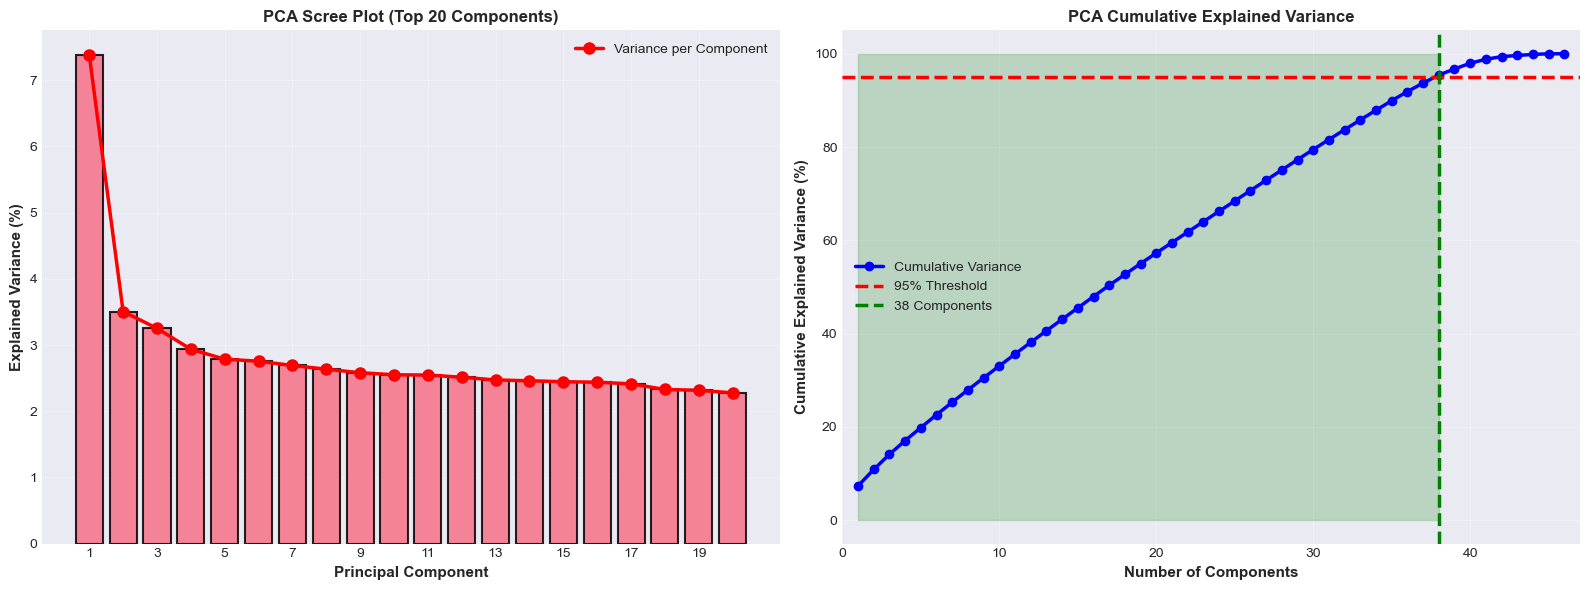


📊 SCREE PLOT INTERPRETATION:
  • Look for the 'elbow' where variance drops sharply
  • Components after the elbow add diminishing value
  • In our case, first 38 components are most informative
  • These 38 PCs capture 95.4% of total variance


In [11]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
n_show = min(20, len(explained_variance_ratio))
axes[0].bar(range(1, n_show + 1),
           explained_variance_ratio[:n_show] * 100,
           color=PALETTE[0], edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].plot(range(1, n_show + 1),
            explained_variance_ratio[:n_show] * 100,
            'ro-', linewidth=2.5, markersize=8, label='Variance per Component')
axes[0].set_xlabel('Principal Component', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold', fontsize=11)
axes[0].set_title(f'PCA Scree Plot (Top {n_show} Components)', fontweight='bold', fontsize=12)
axes[0].set_xticks(range(1, n_show + 1, max(1, n_show // 10)))
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1),
            cumulative_variance_ratio * 100,
            'bo-', linewidth=2.5, markersize=6, label='Cumulative Variance')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=2.5, label='95% Threshold')
axes[1].axvline(x=n_components_95, color='green', linestyle='--', linewidth=2.5,
               label=f'{n_components_95} Components')
axes[1].fill_between(range(1, n_components_95 + 1),
                     0, 100, alpha=0.2, color='green')
axes[1].set_xlabel('Number of Components', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold', fontsize=11)
axes[1].set_title('PCA Cumulative Explained Variance', fontweight='bold', fontsize=12)
axes[1].set_xlim(0, min(len(cumulative_variance_ratio) + 1, 50))
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 SCREE PLOT INTERPRETATION:")
print(f"  • Look for the 'elbow' where variance drops sharply")
print(f"  • Components after the elbow add diminishing value")
print(f"  • In our case, first {n_components_95} components are most informative")
print(f"  • These {n_components_95} PCs capture {cumulative_variance_ratio[n_components_95-1]*100:.1f}% of total variance")


FEATURE LOADINGS ON TOP 5 PRINCIPAL COMPONENTS

Loadings show how much each feature contributes to each PC
Values near ±1 indicate strong contribution, near 0 indicates weak contribution

⚠️ Note: Showing top 10 features by absolute loading for each PC
    (Full feature set has 46 features)


PC1 Top Features:
  player_engagement_Low                    +0.463
  log_total_reviews                        -0.454
  log_ownership                            -0.389
  initial_price                            -0.342
  player_engagement_Medium                 -0.324
  avg_recent_players                       -0.240
  review_score                             -0.207
  is_multiplayer_1                         -0.165
  days_since_release                       +0.148
  has_controller_support_1                 -0.136

PC2 Top Features:
  primary_genre_Strategy                   +0.492
  has_controller_support_1                 -0.478
  primary_genre_Indie                      -0.298
  primary_genre_Ad

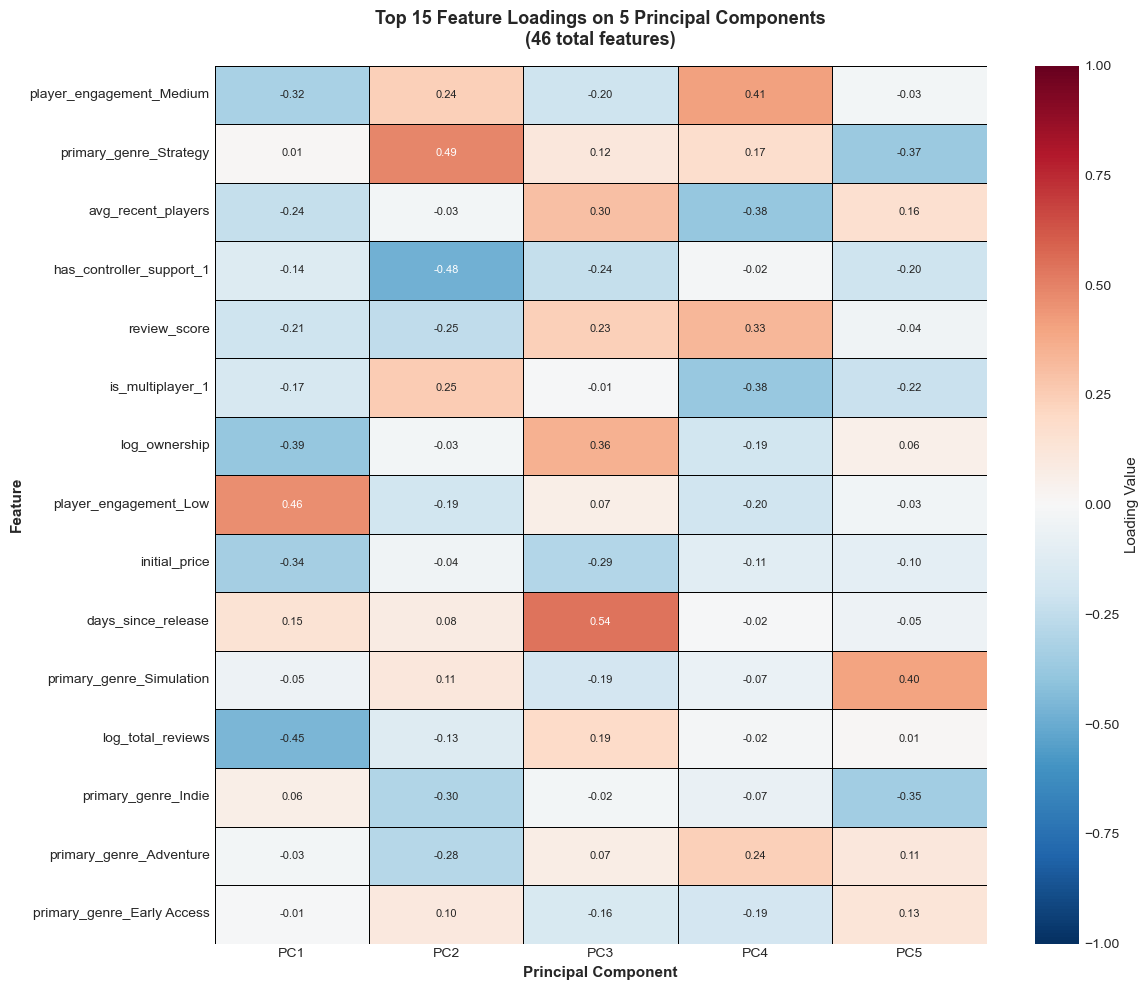


PRINCIPAL COMPONENT INTERPRETATION

PC1 (Explains 7.38% of variance):
  Top 5 Positive Contributors:
    • player_engagement_Low                            (+0.463)
    • days_since_release                               (+0.148)
    • primary_genre_Casual                             (+0.113)
    • primary_genre_Indie                              (+0.064)
    • release_month_7                                  (+0.050)
  Top 5 Negative Contributors:
    • log_total_reviews                                (-0.454)
    • log_ownership                                    (-0.389)
    • initial_price                                    (-0.342)
    • player_engagement_Medium                         (-0.324)
    • avg_recent_players                               (-0.240)

PC2 (Explains 3.51% of variance):
  Top 5 Positive Contributors:
    • primary_genre_Strategy                           (+0.492)
    • is_multiplayer_1                                 (+0.252)
    • player_engagement_Medium   

In [12]:
# Feature loadings on principal components
n_components_show = min(5, n_components_95)

# Create loadings dataframe
loadings_df = pd.DataFrame(
    pca_full.components_[:n_components_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_show)],
    index=pca_features
)

print("\n" + "="*80)
print(f"FEATURE LOADINGS ON TOP {n_components_show} PRINCIPAL COMPONENTS")
print("="*80)
print("\nLoadings show how much each feature contributes to each PC")
print("Values near ±1 indicate strong contribution, near 0 indicates weak contribution\n")

# For large feature sets, only show top contributors in table
if len(pca_features) > 20:
    print(f"⚠️ Note: Showing top 10 features by absolute loading for each PC")
    print(f"    (Full feature set has {len(pca_features)} features)\n")
    
    for i in range(n_components_show):
        print(f"\nPC{i+1} Top Features:")
        pc_loadings = loadings_df.iloc[:, i].abs().sort_values(ascending=False).head(10)
        for feature in pc_loadings.index:
            loading = loadings_df.loc[feature, f'PC{i+1}']
            print(f"  {feature:40} {loading:+.3f}")
else:
    # Show full table for smaller feature sets
    print(loadings_df.round(3))

# Visualize loadings as heatmap
# For large feature sets, show only top contributors
if len(pca_features) > 30:
    # Get top 15 features by total absolute loading across all shown PCs
    total_loading = loadings_df.abs().sum(axis=1).sort_values(ascending=False)
    top_features = total_loading.head(15).index
    loadings_to_plot = loadings_df.loc[top_features]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(loadings_to_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
               cbar_kws={'label': 'Loading Value'},
               linewidths=0.5, linecolor='black',
               vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 8})
    ax.set_title(f'Top 15 Feature Loadings on {n_components_show} Principal Components\n({len(pca_features)} total features)',
                fontweight='bold', fontsize=13, pad=15)
else:
    # Show all features for smaller sets
    fig, ax = plt.subplots(figsize=(10, max(8, len(pca_features) * 0.3)))
    sns.heatmap(loadings_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
               cbar_kws={'label': 'Loading Value'},
               linewidths=0.5, linecolor='black',
               vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Feature Loadings on Top {n_components_show} Principal Components',
                fontweight='bold', fontsize=13, pad=15)

ax.set_xlabel('Principal Component', fontweight='bold', fontsize=11)
ax.set_ylabel('Feature', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# Interpret principal components
print(f"\n" + "="*80)
print("PRINCIPAL COMPONENT INTERPRETATION")
print("="*80)

for i in range(n_components_show):
    print(f"\nPC{i+1} (Explains {explained_variance_ratio[i]*100:.2f}% of variance):")
    
    # Get top 5 positive and negative loadings (more for larger sets)
    pc_loadings = loadings_df.iloc[:, i]
    n_show = 5 if len(pca_features) > 20 else 3
    top_positive = pc_loadings.nlargest(n_show)
    top_negative = pc_loadings.nsmallest(n_show)
    
    print(f"  Top {n_show} Positive Contributors:")
    for feature, loading in top_positive.items():
        # Truncate long feature names
        feature_display = feature[:45] + "..." if len(feature) > 45 else feature
        print(f"    • {feature_display:48} ({loading:+.3f})")
    
    if abs(top_negative.iloc[0]) > 0.2:  # Lower threshold for larger sets
        print(f"  Top {n_show} Negative Contributors:")
        for feature, loading in top_negative.items():
            feature_display = feature[:45] + "..." if len(feature) > 45 else feature
            print(f"    • {feature_display:48} ({loading:+.3f})")

print(f"\n📊 HOW TO INTERPRET LOADINGS:")
print(f"  • High positive loading: feature increases as PC increases")
print(f"  • High negative loading: feature decreases as PC increases")
print(f"  • Loading near 0: feature doesn't contribute to this PC")
print(f"  • PCs are orthogonal (uncorrelated) by construction")

if len(pca_features) > 20:
    print(f"\n💡 INSIGHT FOR {len(pca_features)} FEATURES:")
    print(f"  • One-hot encoded categoricals create many binary features")
    print(f"  • PCA shows which genre/tier combinations drive variance")
    print(f"  • Example: 'primary_genre_Action' high loading = Action games vary strongly on this PC")
    print(f"  • Numeric features (price, ownership) typically dominate early PCs")

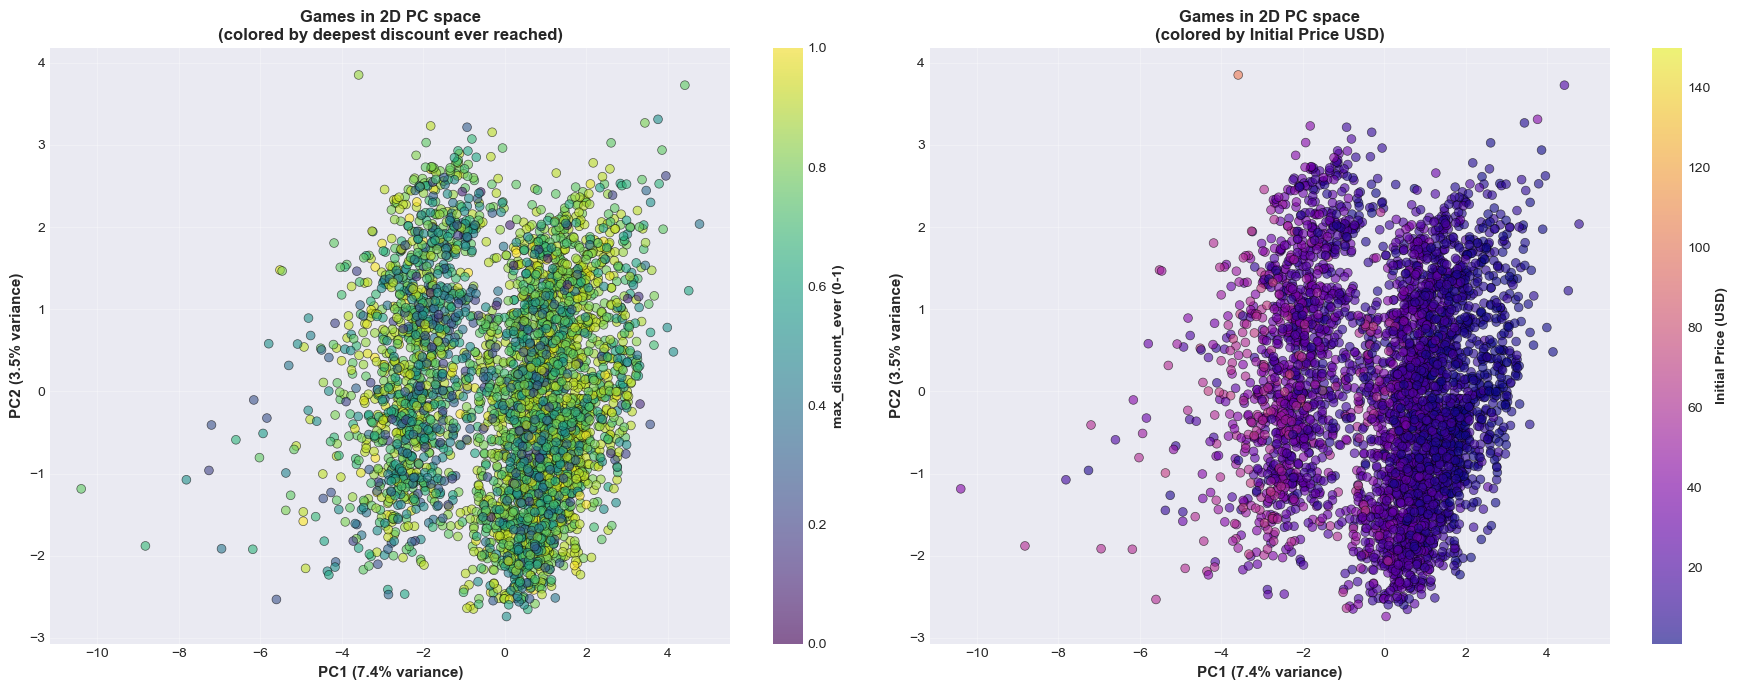

In [13]:
# 2D visualization of games in PC space, colored by max_discount_ever
# (notebook 04's regression target). The old version colored by value_retention_tier,
# which was removed during the cleaning audit.

y_disc = df.loc[X_pca.index, 'max_discount_ever'] / 100   # 0-1 scale
y_price = df.loc[X_pca.index, 'initial_price']            # USD MSRP

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: colored by max_discount_ever (continuous viridis colormap)
sc1 = axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                      c=y_disc, cmap='viridis', alpha=0.6, s=40,
                      edgecolors='black', linewidths=0.5,
                      vmin=0, vmax=1)
cbar = plt.colorbar(sc1, ax=axes[0])
cbar.set_label('max_discount_ever (0-1)', fontweight='bold', fontsize=10)
axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)',
                   fontweight='bold', fontsize=11)
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)',
                   fontweight='bold', fontsize=11)
axes[0].set_title('Games in 2D PC space\n(colored by deepest discount ever reached)',
                  fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: colored by initial_price (USD)
sc2 = axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                      c=y_price, cmap='plasma', alpha=0.6, s=40,
                      edgecolors='black', linewidths=0.5)
cbar = plt.colorbar(sc2, ax=axes[1])
cbar.set_label('Initial Price (USD)', fontweight='bold', fontsize=10)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)',
                   fontweight='bold', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)',
                   fontweight='bold', fontsize=11)
axes[1].set_title('Games in 2D PC space\n(colored by Initial Price USD)',
                  fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Headline target view

Quick stats on the regression target (`max_discount_ever`) plus ITAD coverage. Useful before the deeper regression-distribution panels below.


In [14]:
target = df['max_discount_ever'] / 100
itad_covered = df['has_itad_data'].sum() if 'has_itad_data' in df.columns else df['max_discount_ever'].notna().sum()

print("HEADLINE TARGET VIEW")
print("-" * 60)
print(f"Games in modeling dataset            : {len(df):>5,}")
print(f"With ITAD price-history coverage     : {itad_covered:>5,}  ({itad_covered/len(df)*100:.1f}%)")
print()
print(f"max_discount_ever / 100 (regression target):")
print(f"  mean   : {target.mean():.3f}")
print(f"  median : {target.median():.3f}")
print(f"  std    : {target.std():.3f}")
print(f"  share >= 50% off ever: {(target >= 0.5).mean()*100:.1f}%")
print(f"  share >= 75% off ever: {(target >= 0.75).mean()*100:.1f}%")


HEADLINE TARGET VIEW
------------------------------------------------------------
Games in modeling dataset            : 3,945
With ITAD price-history coverage     : 3,945  (100.0%)

max_discount_ever / 100 (regression target):
  mean   : 0.728
  median : 0.800
  std    : 0.190
  share >= 50% off ever: 89.3%
  share >= 75% off ever: 64.7%


---
## 3. Target Variable Analysis
---

We examine both modeling targets:
- **Regression:** `current_price` (PHP) — continuous price prediction
- **Classification:** `value_retention_tier` — categorical price retention behavior

### Why these targets matter:
- `current_price` tells us **what** a game sells for today
- `value_retention_tier` tells us **how** a game's pricing strategy behaves over time
- Together, they capture both absolute pricing and relative depreciation patterns

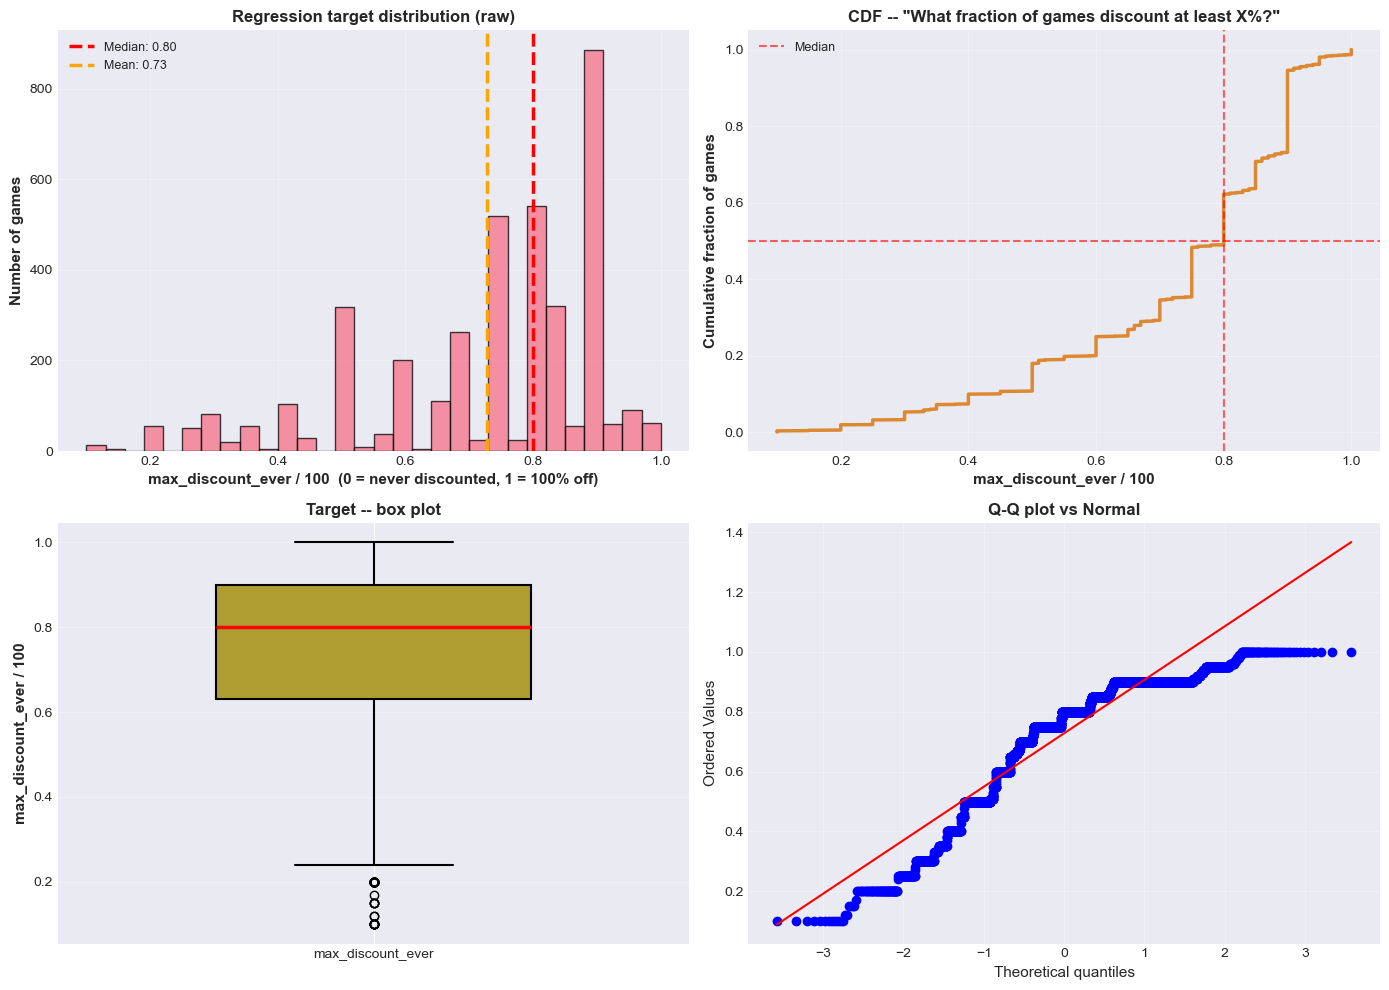

REGRESSION TARGET: max_discount_ever / 100  (notebook 04's regression target)

Descriptive Statistics:
  Count:      3,945
  Mean:       0.728
  Median:     0.800
  Std Dev:    0.190
  Min:        0.100
  Max:        1.000
  Q1 (25%):   0.630
  Q3 (75%):   0.900

Distribution shape:
  Skewness:   -1.100
  Kurtosis:   0.491

Threshold concentration (share of games):
  At least 25% off ever:   98.1%
  At least 50% off ever:   89.3%
  At least 75% off ever:   64.7%

INTERPRETATION:
  Distribution is HEAVILY LEFT-SKEWED (skew = -1.10).
  Most games eventually reach a deep discount (Steam-sale floor at 75%);
  the rare cases are games that resist discounting.
  RECOMMENDATION: model directly on the 0-1 scale; tree-based models handle
  the bimodal/clustered nature without needing a transform.


In [15]:
# === REGRESSION TARGET: max_discount_ever (matches notebook 04's regression target) ===
# We model the deepest discount each game has ever reached, on a 0-1 scale.
# This is the actual y in notebook 04's Step 4.4 regression.

target = (df['max_discount_ever'] / 100).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original distribution
axes[0, 0].hist(target, bins=30, edgecolor='black', alpha=0.75, color=PALETTE[0])
axes[0, 0].axvline(target.median(), color='red', linestyle='--', linewidth=2.5,
                   label=f'Median: {target.median():.2f}')
axes[0, 0].axvline(target.mean(), color='orange', linestyle='--', linewidth=2.5,
                   label=f'Mean: {target.mean():.2f}')
axes[0, 0].set_xlabel('max_discount_ever / 100  (0 = never discounted, 1 = 100% off)',
                       fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('Number of games', fontweight='bold', fontsize=11)
axes[0, 0].set_title('Regression target distribution (raw)', fontweight='bold', fontsize=12)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# CDF of the target -- shows the cumulative share of games that hit each depth
sorted_target = np.sort(target.values)
cdf_y = np.arange(1, len(sorted_target) + 1) / len(sorted_target)
axes[0, 1].plot(sorted_target, cdf_y, linewidth=2.5, color=PALETTE[1])
axes[0, 1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Median')
axes[0, 1].axvline(target.median(), color='red', linestyle='--', linewidth=1.5, alpha=0.6)
axes[0, 1].set_xlabel('max_discount_ever / 100', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Cumulative fraction of games', fontweight='bold', fontsize=11)
axes[0, 1].set_title('CDF -- "What fraction of games discount at least X%?"',
                     fontweight='bold', fontsize=12)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Box plot -- outliers + spread
bp = axes[1, 0].boxplot(target, vert=True, patch_artist=True, widths=0.5,
                        boxprops=dict(facecolor=PALETTE[2], edgecolor='black', linewidth=1.5),
                        medianprops=dict(color='red', linewidth=2.5),
                        whiskerprops=dict(color='black', linewidth=1.5),
                        capprops=dict(color='black', linewidth=1.5))
axes[1, 0].set_ylabel('max_discount_ever / 100', fontweight='bold', fontsize=11)
axes[1, 0].set_title('Target -- box plot', fontweight='bold', fontsize=12)
axes[1, 0].set_xticklabels(['max_discount_ever'])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Q-Q plot for normality assessment
stats.probplot(target, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot vs Normal', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)
print("REGRESSION TARGET: max_discount_ever / 100  (notebook 04's regression target)")
print("="*80)
print(f"\nDescriptive Statistics:")
print(f"  Count:      {len(target):,}")
print(f"  Mean:       {target.mean():.3f}")
print(f"  Median:     {target.median():.3f}")
print(f"  Std Dev:    {target.std():.3f}")
print(f"  Min:        {target.min():.3f}")
print(f"  Max:        {target.max():.3f}")
print(f"  Q1 (25%):   {target.quantile(0.25):.3f}")
print(f"  Q3 (75%):   {target.quantile(0.75):.3f}")
print(f"\nDistribution shape:")
print(f"  Skewness:   {target.skew():.3f}")
print(f"  Kurtosis:   {target.kurtosis():.3f}")

# Concentration -- where does most of the mass sit?
hit_75 = (target >= 0.75).mean() * 100
hit_50 = (target >= 0.50).mean() * 100
hit_25 = (target >= 0.25).mean() * 100
print(f"\nThreshold concentration (share of games):")
print(f"  At least 25% off ever:  {hit_25:>5.1f}%")
print(f"  At least 50% off ever:  {hit_50:>5.1f}%")
print(f"  At least 75% off ever:  {hit_75:>5.1f}%")

print(f"\nINTERPRETATION:")
if target.skew() < -1:
    print(f"  Distribution is HEAVILY LEFT-SKEWED (skew = {target.skew():.2f}).")
    print(f"  Most games eventually reach a deep discount (Steam-sale floor at 75%);")
    print(f"  the rare cases are games that resist discounting.")
elif target.skew() < -0.3:
    print(f"  Distribution is moderately left-skewed (skew = {target.skew():.2f}).")
else:
    print(f"  Distribution is approximately symmetric (skew = {target.skew():.2f}).")
print(f"  RECOMMENDATION: model directly on the 0-1 scale; tree-based models handle")
print(f"  the bimodal/clustered nature without needing a transform.")


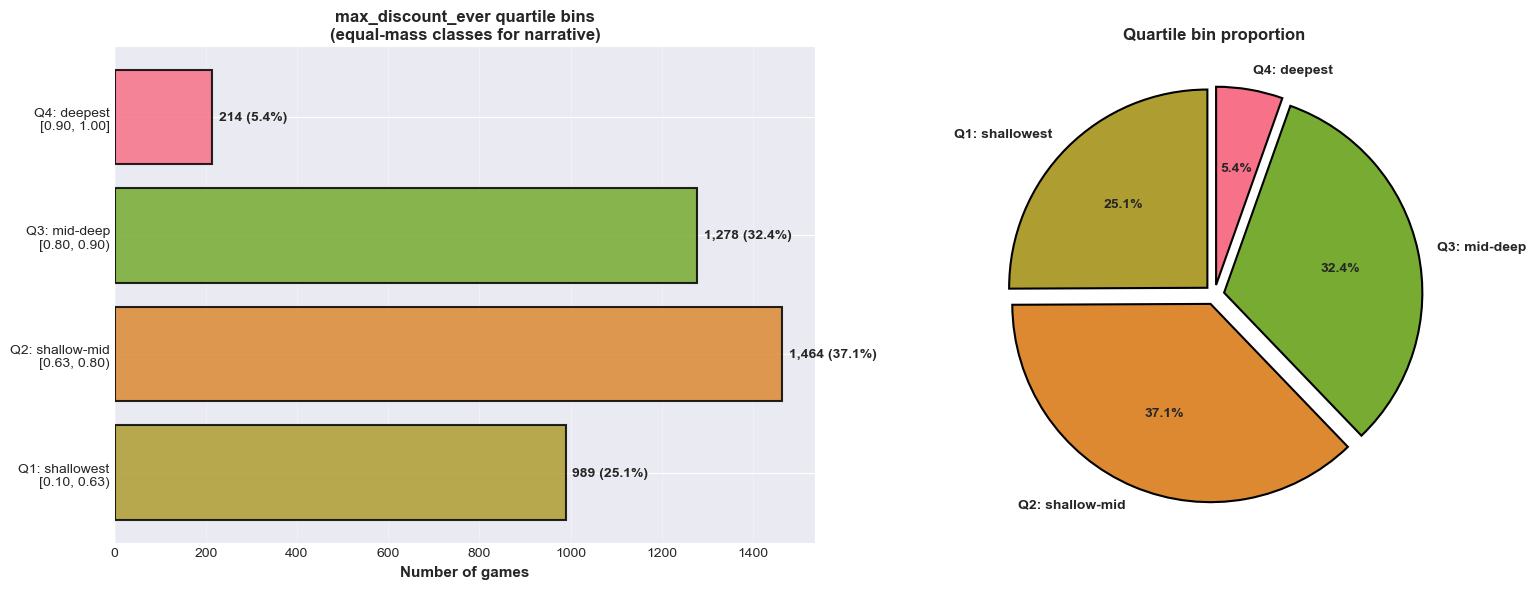


CLASSIFICATION VIEW: quartile bins on max_discount_ever / 100

By construction each tier holds ~25% of the dataset.
Tier boundaries (data-derived, not hand-picked):
  Q1: shallowest          range [0.10, 0.63)    n =  989  (25.1%)
  Q2: shallow-mid         range [0.63, 0.80)    n = 1,464  (37.1%)
  Q3: mid-deep            range [0.80, 0.90)    n = 1,278  (32.4%)
  Q4: deepest             range [0.90, 1.00]    n =  214  (5.4%)

Note: notebook 04 actually models on the continuous 0-1 target (Step 4.4)
and on a 20-bin ordinal target (Step 4.5). These quartile bins are an EDA
convenience -- they exist only in this cell, not in the cleaned tables.


In [16]:
# === CLASSIFICATION-FRIENDLY VIEW: quartile bins on max_discount_ever ===
# Note: notebook 04's old `value_retention_tier` target was removed in the
# cleaning audit (the boundaries had no research justification, and the
# 'Premium Hold' tier conflicted with the modeling filter). For an EDA bar
# chart we derive 4 quartile-based tiers locally so each tier carries equal
# mass -- this is what we'd do if we wanted to bucket the regression target
# into classes for narrative purposes.

target = (df['max_discount_ever'] / 100).dropna()

# Quartile bins -- equal-mass classes by definition
qbins, qedges = pd.qcut(target, q=4, retbins=True, duplicates='drop',
                        labels=['Q1: shallowest', 'Q2: shallow-mid',
                                'Q3: mid-deep',   'Q4: deepest'])
counts = qbins.value_counts().reindex(qbins.cat.categories)
edge_labels = [f'[{qedges[i]:.2f}, {qedges[i+1]:.2f}{")" if i < len(qedges)-2 else "]"}'
               for i in range(len(qedges) - 1)]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

quartile_colors = [PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[0]]   # cool to hot
y_pos = np.arange(len(counts))
bars = axes[0].barh(y_pos, counts.values, color=quartile_colors,
                    edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f'{lbl}\n{rng}' for lbl, rng in zip(counts.index, edge_labels)])
axes[0].set_xlabel('Number of games', fontweight='bold', fontsize=11)
axes[0].set_title('max_discount_ever quartile bins\n(equal-mass classes for narrative)',
                  fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')
for i, (bar, count) in enumerate(zip(bars, counts.values)):
    pct = (count / counts.sum() * 100)
    axes[0].text(count + counts.max() * 0.01, i, f'{count:,} ({pct:.1f}%)',
                 va='center', fontweight='bold', fontsize=10)

# Pie chart
explode = [0.05] * len(counts)
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            startangle=90, colors=quartile_colors, explode=explode,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
            textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Quartile bin proportion', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CLASSIFICATION VIEW: quartile bins on max_discount_ever / 100")
print("="*80)
print(f"\nBy construction each tier holds ~25% of the dataset.")
print(f"Tier boundaries (data-derived, not hand-picked):")
for tier, rng in zip(counts.index, edge_labels):
    pct = counts[tier] / counts.sum() * 100
    print(f"  {tier:<22}  range {rng:<14}  n = {counts[tier]:>4,}  ({pct:.1f}%)")

print(f"\nNote: notebook 04 actually models on the continuous 0-1 target (Step 4.4)")
print(f"and on a 20-bin ordinal target (Step 4.5). These quartile bins are an EDA")
print(f"convenience -- they exist only in this cell, not in the cleaned tables.")


---
## 4. Feature Distribution Analysis
---

Examining the distribution of key features that will be used in ML models.

**Why this matters:**
- Identifies need for transformations (log, power, etc.)
- Detects outliers that may require handling
- Reveals skewness that affects model assumptions
- Informs scaling strategy (StandardScaler vs RobustScaler)

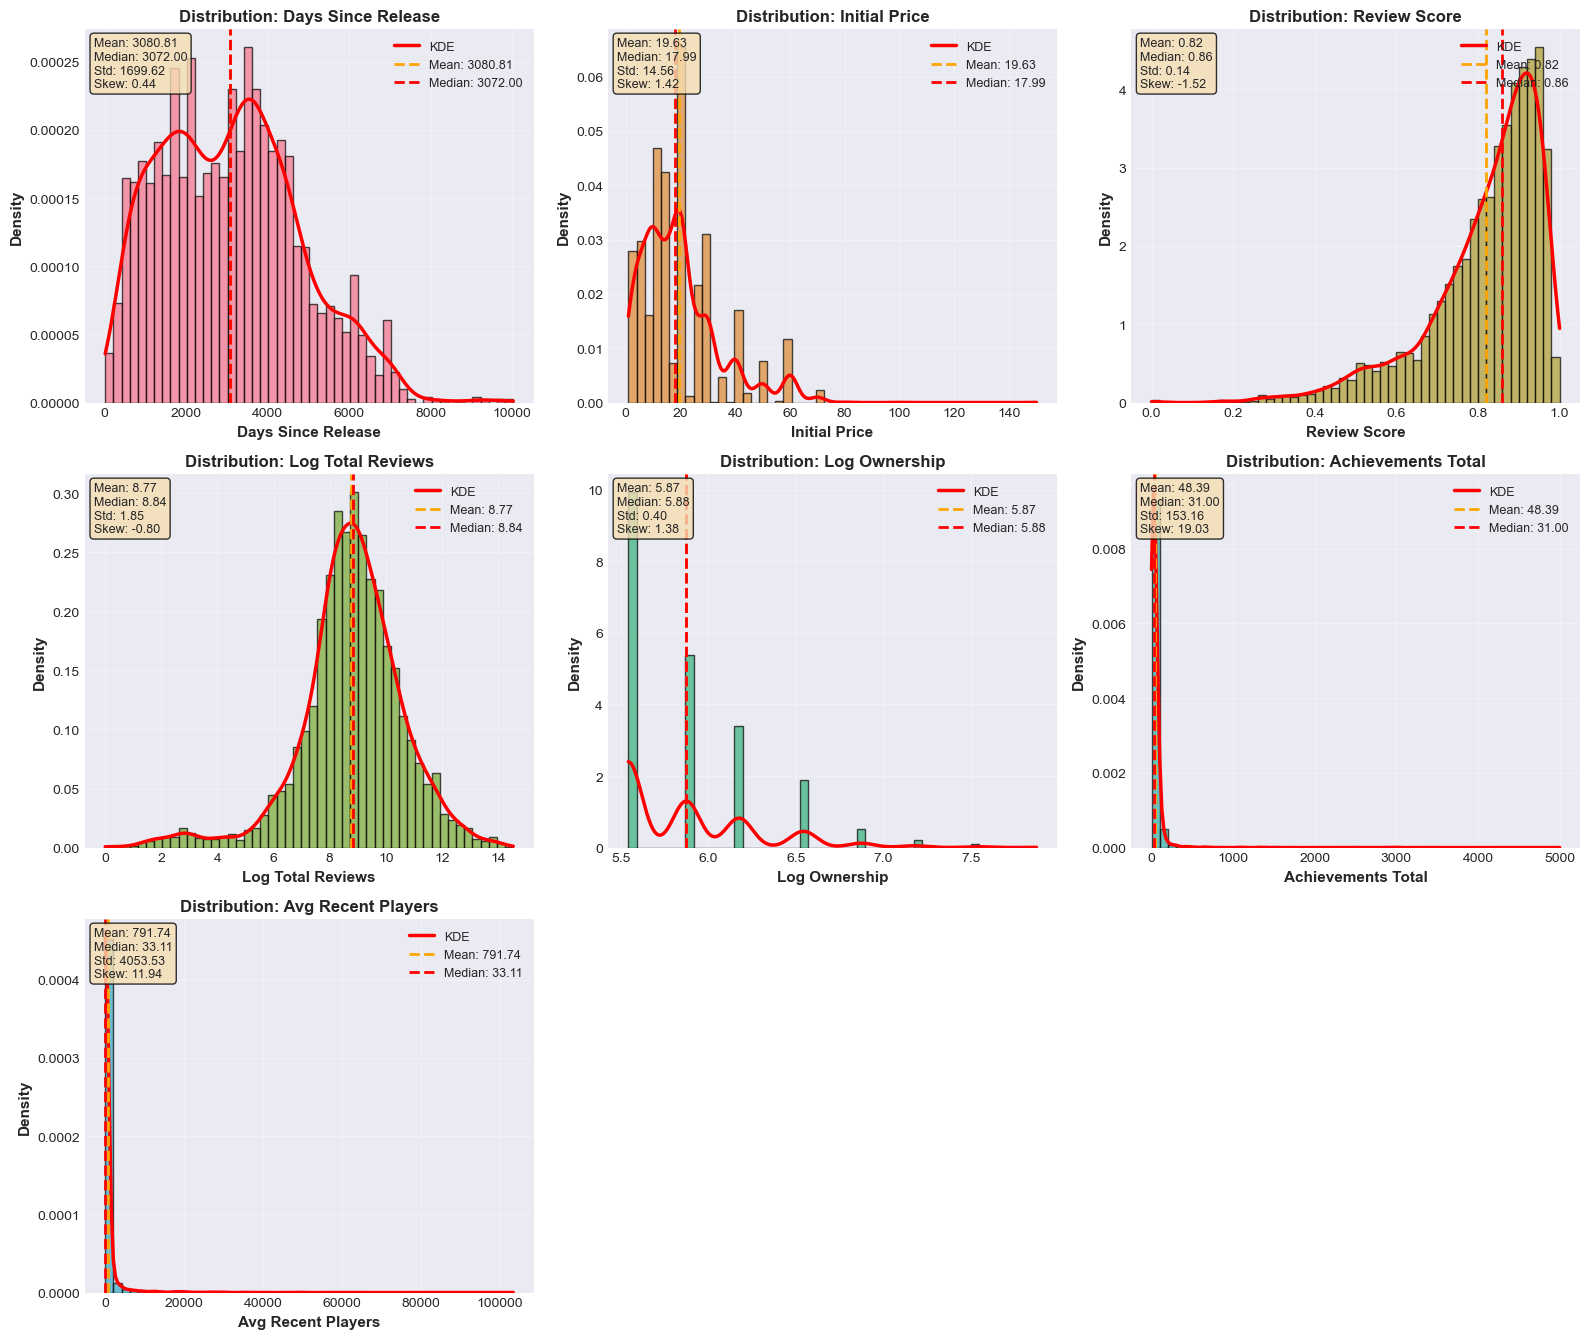


NUMERICAL FEATURES - DISTRIBUTION SUMMARY

days_since_release:
  Range: [12.00, 10029.00]
  Mean ± Std: 3080.81 ± 1699.62
  Skewness: 0.441 (approximately symmetric)

initial_price:
  Range: [0.99, 149.99]
  Mean ± Std: 19.63 ± 14.56
  Skewness: 1.421 (HIGHLY SKEWED - consider log/sqrt transformation)

review_score:
  Range: [0.00, 1.00]
  Mean ± Std: 0.82 ± 0.14
  Skewness: -1.522 (HIGHLY SKEWED - consider log/sqrt transformation)

log_total_reviews:
  Range: [0.00, 14.54]
  Mean ± Std: 8.77 ± 1.85
  Skewness: -0.798 (MODERATELY SKEWED - transformation may help)

log_ownership:
  Range: [5.54, 7.88]
  Mean ± Std: 5.87 ± 0.40
  Skewness: 1.384 (HIGHLY SKEWED - consider log/sqrt transformation)

achievements_total:
  Range: [0.00, 5000.00]
  Mean ± Std: 48.39 ± 153.16
  Skewness: 19.028 (HIGHLY SKEWED - consider log/sqrt transformation)

avg_recent_players:
  Range: [0.00, 103485.44]
  Mean ± Std: 791.74 ± 4053.53
  Skewness: 11.939 (HIGHLY SKEWED - consider log/sqrt transformation)


In [17]:
# Distribution plots for numerical features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4.5))
axes = axes.ravel() if n_features > 1 else [axes]

for idx, feature in enumerate(numeric_features):
    data = df[feature].dropna()
    
    # Histogram with KDE
    axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, 
                   color=PALETTE[idx % len(PALETTE)], density=True)
    
    # Add KDE curve
    if len(data) > 1 and data.std() > 0:
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        axes[idx].plot(x_range, kde(x_range), 'r-', linewidth=2.5, label='KDE')
    
    # Add mean and median lines
    axes[idx].axvline(data.mean(), color='orange', linestyle='--', linewidth=2,
                     label=f'Mean: {data.mean():.2f}')
    axes[idx].axvline(data.median(), color='red', linestyle='--', linewidth=2,
                     label=f'Median: {data.median():.2f}')
    
    axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Density', fontweight='bold', fontsize=11)
    axes[idx].set_title(f'Distribution: {feature.replace("_", " ").title()}',
                       fontweight='bold', fontsize=12)
    axes[idx].legend(fontsize=9, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = (
        f"Mean: {data.mean():.2f}\n"
        f"Median: {data.median():.2f}\n"
        f"Std: {data.std():.2f}\n"
        f"Skew: {data.skew():.2f}"
    )
    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Print distribution summary
print("\n" + "="*80)
print("NUMERICAL FEATURES - DISTRIBUTION SUMMARY")
print("="*80)

for feature in numeric_features:
    data = df[feature].dropna()
    print(f"\n{feature}:")
    print(f"  Range: [{data.min():.2f}, {data.max():.2f}]")
    print(f"  Mean ± Std: {data.mean():.2f} ± {data.std():.2f}")
    print(f"  Skewness: {data.skew():.3f}", end="")
    
    if abs(data.skew()) > 1:
        print(f" (HIGHLY SKEWED - consider log/sqrt transformation)")
    elif abs(data.skew()) > 0.5:
        print(f" (MODERATELY SKEWED - transformation may help)")
    else:
        print(f" (approximately symmetric)")

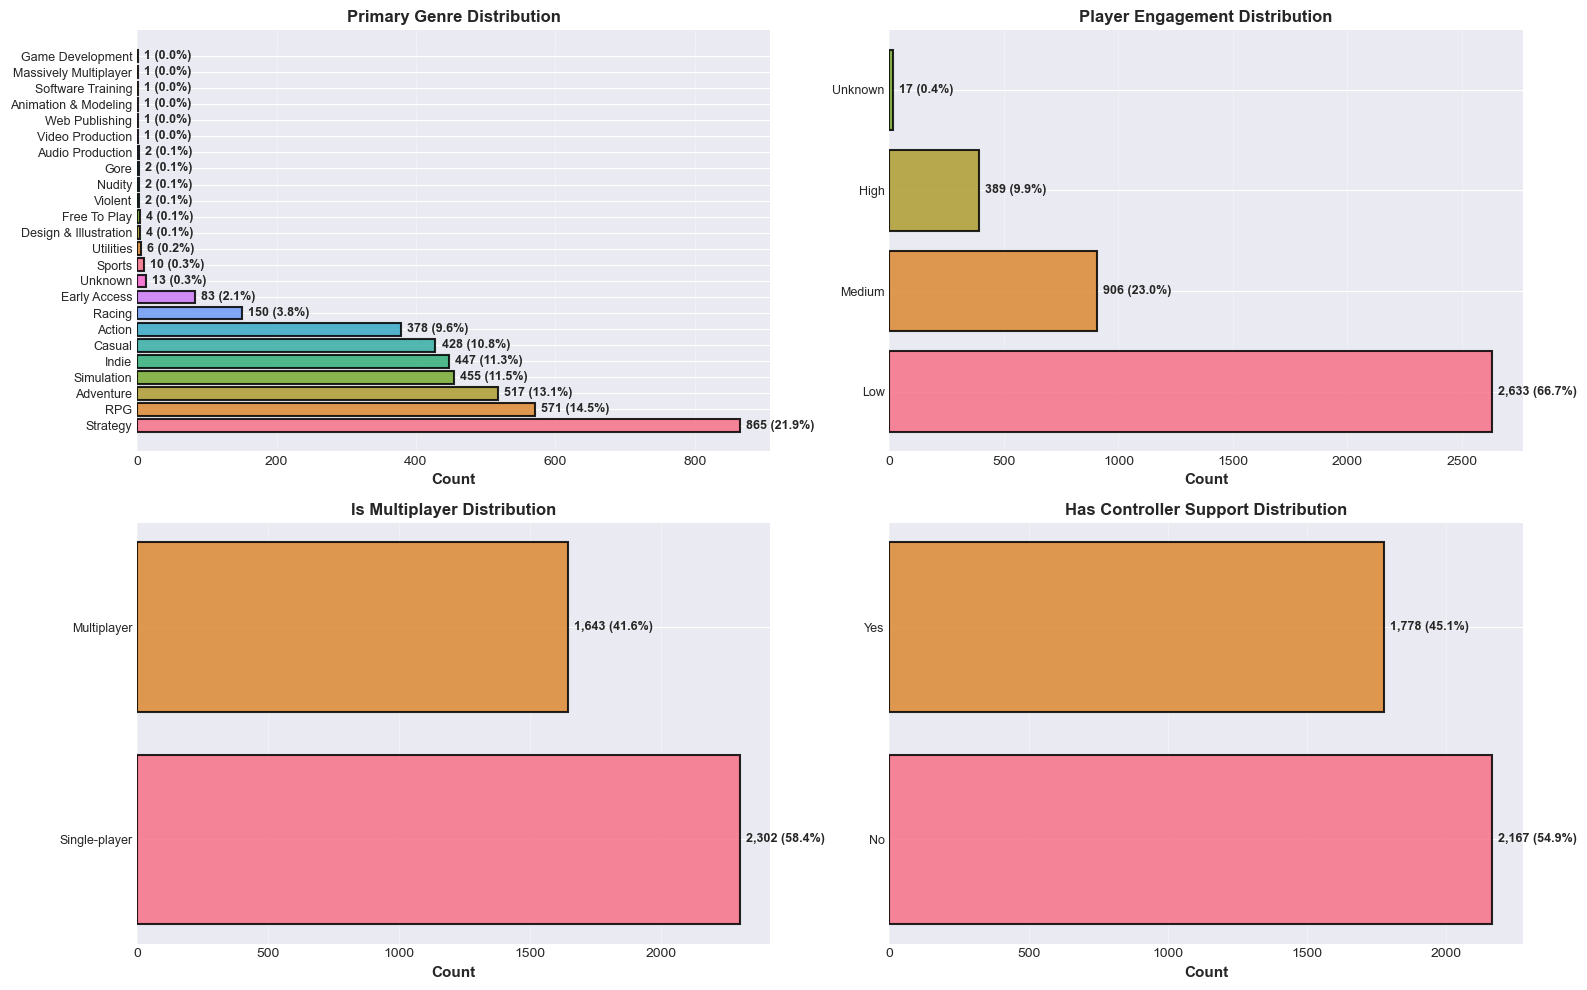


CATEGORICAL FEATURES - SUMMARY

primary_genre:
  Unique values: 24
  Distribution:
    Strategy                865 (21.93%)
    RPG                     571 (14.47%)
    Adventure               517 (13.11%)
    Simulation              455 (11.53%)
    Indie                   447 (11.33%)
    Casual                  428 (10.85%)
    Action                  378 ( 9.58%)
    Racing                  150 ( 3.80%)
    Early Access             83 ( 2.10%)
    Unknown                  13 ( 0.33%)
    Sports                   10 ( 0.25%)
    Utilities                 6 ( 0.15%)
    Design & Illustration      4 ( 0.10%)
    Free To Play              4 ( 0.10%)
    Violent                   2 ( 0.05%)
    Nudity                    2 ( 0.05%)
    Gore                      2 ( 0.05%)
    Audio Production          2 ( 0.05%)
    Video Production          1 ( 0.03%)
    Web Publishing            1 ( 0.03%)
    Animation & Modeling      1 ( 0.03%)
    Software Training         1 ( 0.03%)
    Massively

In [18]:
# Categorical features analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# Show first 4 categorical features
features_to_plot = categorical_features[:min(4, len(categorical_features))]

for idx, feature in enumerate(features_to_plot):
    if feature == 'is_multiplayer':
        # Convert binary to labels
        plot_data = df[feature].map({0: 'Single-player', 1: 'Multiplayer', np.nan: 'Unknown'})
    elif feature == 'has_controller_support':
        plot_data = df[feature].map({0: 'No', 1: 'Yes', np.nan: 'Unknown'})
    else:
        plot_data = df[feature].fillna('Unknown')
    
    value_counts = plot_data.value_counts()
    
    # Horizontal bar plot
    y_pos = np.arange(len(value_counts))
    colors_list = [PALETTE[i % len(PALETTE)] for i in range(len(value_counts))]
    
    bars = axes[idx].barh(y_pos, value_counts.values, color=colors_list,
                          edgecolor='black', linewidth=1.5, alpha=0.85)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(value_counts.index, fontsize=9)
    axes[idx].set_xlabel('Count', fontweight='bold', fontsize=11)
    axes[idx].set_title(f'{feature.replace("_", " ").title()} Distribution',
                       fontweight='bold', fontsize=12)
    axes[idx].grid(True, alpha=0.3, axis='x')
    
    # Add count and percentage labels
    total = value_counts.sum()
    for i, (bar, count) in enumerate(zip(bars, value_counts.values)):
        pct = (count / total * 100)
        axes[idx].text(count + max(value_counts.values)*0.01, i,
                      f'{count:,} ({pct:.1f}%)',
                      va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print categorical summary
print("\n" + "="*80)
print("CATEGORICAL FEATURES - SUMMARY")
print("="*80)

for feature in categorical_features:
    if feature == 'is_multiplayer':
        plot_data = df[feature].map({0: 'Single-player', 1: 'Multiplayer', np.nan: 'Unknown'})
    elif feature == 'has_controller_support':
        plot_data = df[feature].map({0: 'No', 1: 'Yes', np.nan: 'Unknown'})
    else:
        plot_data = df[feature].fillna('Unknown')
    
    value_counts = plot_data.value_counts()
    print(f"\n{feature}:")
    print(f"  Unique values: {len(value_counts)}")
    print(f"  Distribution:")
    for cat, count in value_counts.items():
        pct = count / len(df) * 100
        print(f"    {str(cat):20} {count:6,} ({pct:5.2f}%)")

---
## 5. Correlation Analysis & Multicollinearity
---

### Why This Matters:
- **Multicollinearity** (high correlation between features) can cause:
  - Unstable coefficient estimates in linear models
  - Difficulty interpreting feature importance
  - Numerical instability in model fitting
- Tree-based models (Random Forest, XGBoost) are **robust to multicollinearity**
- Linear models (Linear Regression, Logistic Regression) are **sensitive to it**

### Thresholds:
- **|r| > 0.9:** SEVERE multicollinearity — remove one feature from pair
- **|r| > 0.7:** MODERATE multicollinearity — consider removal or regularization
- **|r| < 0.7:** Generally acceptable

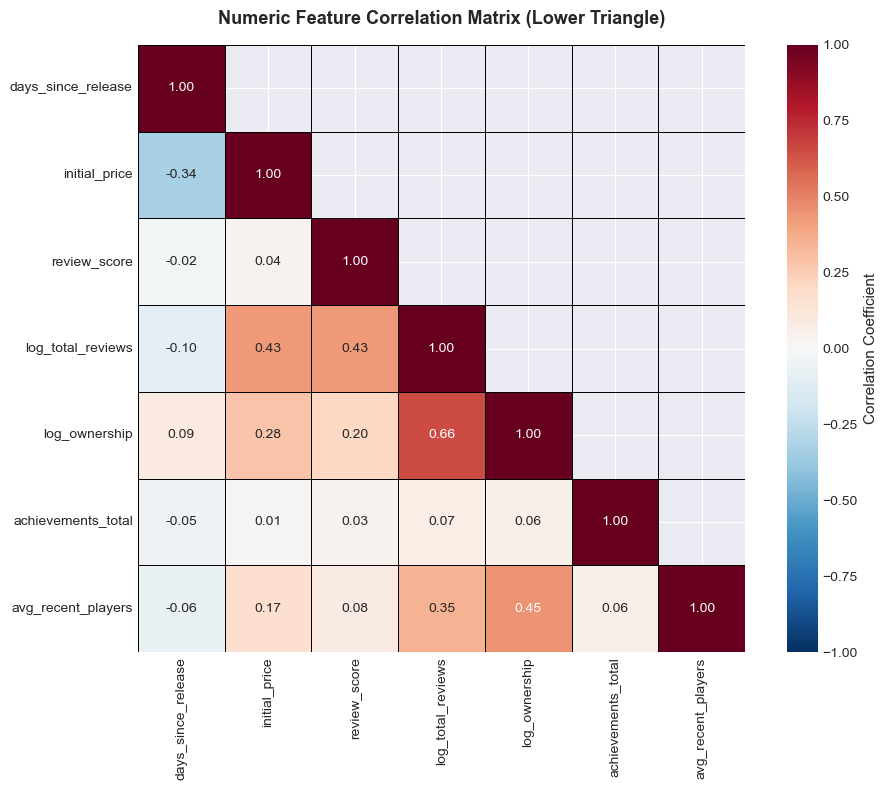

MULTICOLLINEARITY ANALYSIS

⚠️ SEVERE MULTICOLLINEARITY (|r| > 0.9):
  ✓ No severe multicollinearity detected

⚠️ MODERATE MULTICOLLINEARITY (|r| > 0.7):
  ✓ No moderate multicollinearity detected

✅ All numeric feature correlations are acceptable (|r| < 0.7)
  • Numeric features are relatively independent
  • Safe to use all features in modeling
  • Both linear and tree-based models should work well


In [19]:
# Correlation analysis on numeric features only
# (One-hot encoded features are expected to be uncorrelated)

numeric_corr_matrix = df[numeric_features].corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Mask upper triangle
mask = np.triu(np.ones_like(numeric_corr_matrix, dtype=bool), k=1)

sns.heatmap(numeric_corr_matrix, mask=mask, annot=True, fmt='.2f',
           cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           cbar_kws={'label': 'Correlation Coefficient'},
           linewidths=0.5, linecolor='black',
           square=True, ax=ax)

ax.set_title('Numeric Feature Correlation Matrix (Lower Triangle)',
            fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
high_corr_pairs = []
moderate_corr_pairs = []

for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        corr = numeric_corr_matrix.iloc[i, j]
        if abs(corr) > 0.9:
            high_corr_pairs.append((numeric_features[i], numeric_features[j], corr))
        elif abs(corr) > 0.7:
            moderate_corr_pairs.append((numeric_features[i], numeric_features[j], corr))

print("="*80)
print("MULTICOLLINEARITY ANALYSIS")
print("="*80)

print("\n⚠️ SEVERE MULTICOLLINEARITY (|r| > 0.9):")
if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1:25} <-> {feat2:25} r={corr:+.3f}")
    print(f"\n  ACTION REQUIRED: Remove one feature from each pair")
else:
    print(f"  ✓ No severe multicollinearity detected")

print("\n⚠️ MODERATE MULTICOLLINEARITY (|r| > 0.7):")
if moderate_corr_pairs:
    for feat1, feat2, corr in sorted(moderate_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1:25} <-> {feat2:25} r={corr:+.3f}")
    print(f"\n  RECOMMENDATION: Consider feature selection or use regularization (Ridge/Lasso)")
else:
    print(f"  ✓ No moderate multicollinearity detected")

if not high_corr_pairs and not moderate_corr_pairs:
    print("\n✅ All numeric feature correlations are acceptable (|r| < 0.7)")
    print("  • Numeric features are relatively independent")
    print("  • Safe to use all features in modeling")
    print("  • Both linear and tree-based models should work well")

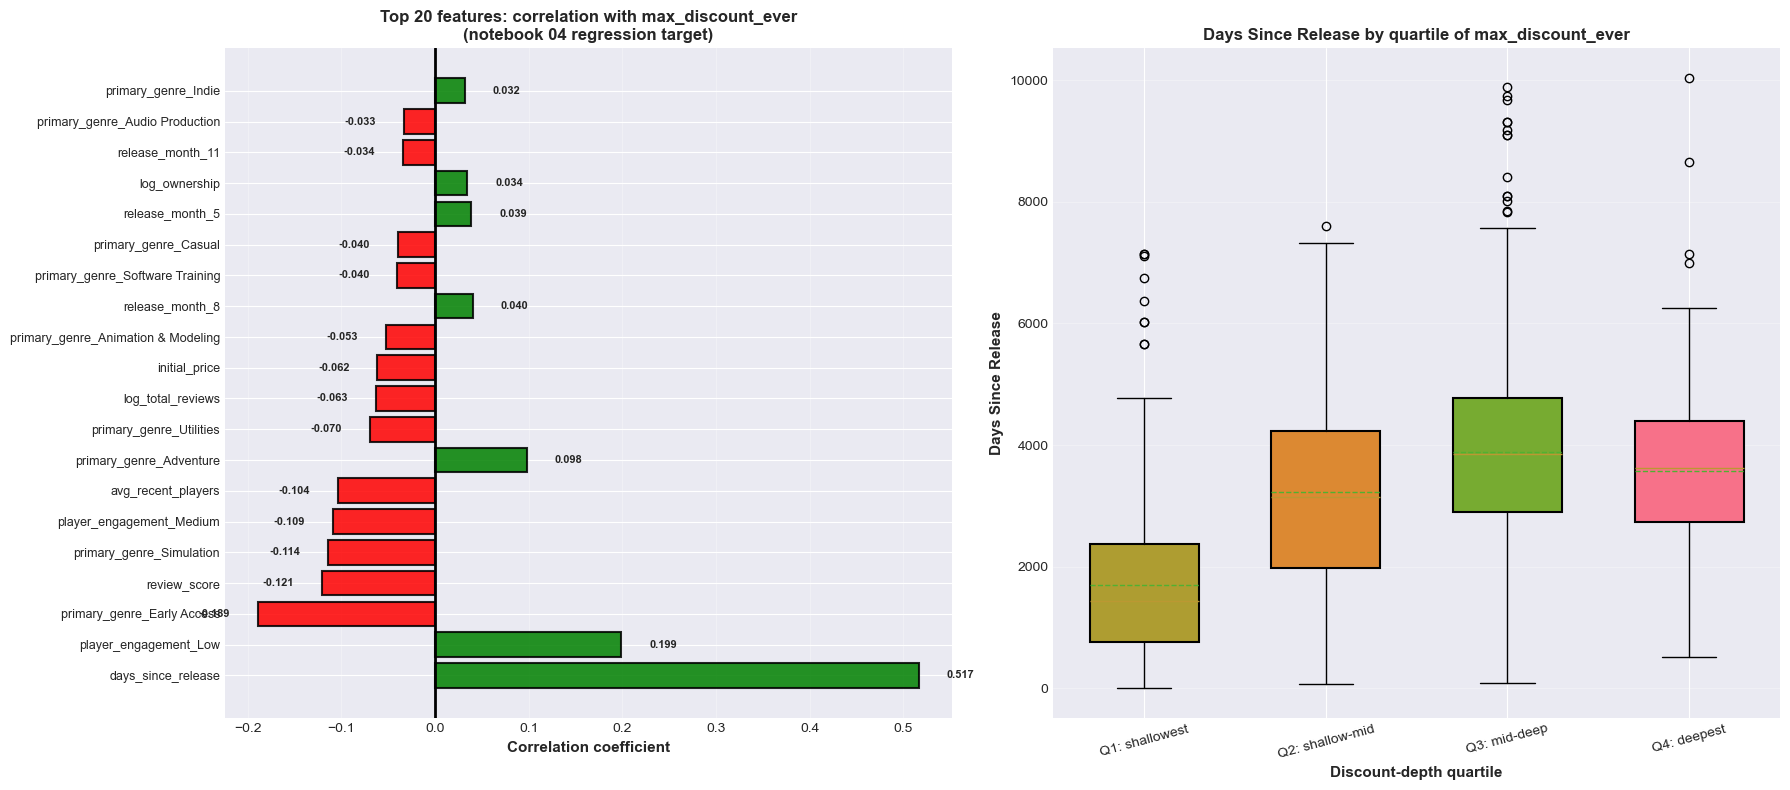


FEATURE CORRELATION WITH max_discount_ever  (regression target)

Top 10 features overall (by |correlation|):
 1. days_since_release                               |r|=0.517  (r=+0.517, Positive)
 2. player_engagement_Low                            |r|=0.199  (r=+0.199, Positive)
 3. primary_genre_Early Access                       |r|=0.189  (r=-0.189, Negative)
 4. review_score                                     |r|=0.121  (r=-0.121, Negative)
 5. primary_genre_Simulation                         |r|=0.114  (r=-0.114, Negative)
 6. player_engagement_Medium                         |r|=0.109  (r=-0.109, Negative)
 7. avg_recent_players                               |r|=0.104  (r=-0.104, Negative)
 8. primary_genre_Adventure                          |r|=0.098  (r=+0.098, Positive)
 9. primary_genre_Utilities                          |r|=0.070  (r=-0.070, Negative)
10. log_total_reviews                                |r|=0.063  (r=-0.063, Negative)

Top 5 NUMERIC features (excluding one-h

In [20]:
# Feature correlations with the regression target (max_discount_ever / 100).
# Replaces the old version which correlated against current_price (PHP) and
# panelled box plots by the now-removed value_retention_tier.

# Align the target with X_full's index and append it for correlation calc
y_target = df.loc[X_full.index, 'max_discount_ever'] / 100
X_with_target = X_full.copy()
X_with_target['max_discount_ever'] = y_target

# Calculate correlations
target_corr = X_with_target.corr()['max_discount_ever'].drop('max_discount_ever')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# For visualization, show top 20 features
n_features_show = min(20, len(target_corr_sorted))
target_corr_top = target_corr_sorted.head(n_features_show)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: top 20 features by |correlation| with the target
y_pos = np.arange(len(target_corr_top))
colors = ['red' if target_corr[feat] < 0 else 'green'
          for feat in target_corr_top.index]
bars = axes[0].barh(y_pos, target_corr[target_corr_top.index],
                    color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_yticks(y_pos)
display_names = [name[:35] + "..." if len(name) > 35 else name
                 for name in target_corr_top.index]
axes[0].set_yticklabels(display_names, fontsize=9)
axes[0].set_xlabel('Correlation coefficient', fontweight='bold', fontsize=11)
axes[0].set_title(f'Top {n_features_show} features: correlation with max_discount_ever\n'
                  f'(notebook 04 regression target)',
                  fontweight='bold', fontsize=12)
axes[0].axvline(x=0, color='black', linewidth=2)
axes[0].grid(True, alpha=0.3, axis='x')
for i, feature in enumerate(target_corr_top.index):
    corr = target_corr[feature]
    x_pos = corr + (0.03 if corr > 0 else -0.03)
    ha = 'left' if corr > 0 else 'right'
    axes[0].text(x_pos, i, f'{corr:.3f}', va='center', ha=ha,
                 fontweight='bold', fontsize=8)

# Right panel: best NUMERIC predictor split by quartile of the target
numeric_corrs = target_corr[numeric_features]
key_feature = numeric_corrs.abs().idxmax()

# Build quartile bins on the target -- equal-mass classes
quartile = pd.qcut(y_target, q=4, duplicates='drop',
                   labels=['Q1: shallowest', 'Q2: shallow-mid',
                           'Q3: mid-deep',   'Q4: deepest'])
qcolors = [PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[0]]

data_to_plot = [df.loc[X_full.index][quartile == q][key_feature].dropna()
                for q in quartile.cat.categories]

bp = axes[1].boxplot(data_to_plot, labels=quartile.cat.categories,
                     patch_artist=True, widths=0.6,
                     showmeans=True, meanline=True)
for patch, color in zip(bp['boxes'], qcolors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

axes[1].set_ylabel(key_feature.replace('_', ' ').title(),
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel('Discount-depth quartile', fontweight='bold', fontsize=11)
axes[1].set_title(f'{key_feature.replace("_", " ").title()} by quartile of max_discount_ever',
                  fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# --- summary text ---
print("\n" + "="*80)
print("FEATURE CORRELATION WITH max_discount_ever  (regression target)")
print("="*80)

print(f"\nTop 10 features overall (by |correlation|):")
for i, feature in enumerate(target_corr_sorted.head(10).index, 1):
    abs_corr = target_corr_sorted[feature]
    corr     = target_corr[feature]
    direction = "Positive" if corr > 0 else "Negative"
    feature_display = feature[:45] + "..." if len(feature) > 45 else feature
    print(f"{i:2d}. {feature_display:<48} |r|={abs_corr:.3f}  (r={corr:+.3f}, {direction})")

print(f"\nTop 5 NUMERIC features (excluding one-hot encoded):")
numeric_corr_sorted = numeric_corrs.abs().sort_values(ascending=False)
for i, feature in enumerate(numeric_corr_sorted.head(5).index, 1):
    abs_corr = numeric_corr_sorted[feature]
    corr     = target_corr[feature]
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{i}. {feature:<25} |r|={abs_corr:.3f}  (r={corr:+.3f}, {direction})")

print(f"\nINTERPRETATION:")
top_feature = target_corr_sorted.index[0]
top_corr    = target_corr[top_feature]
print(f"  Strongest predictor overall: {top_feature}  (r = {top_corr:+.3f})")
top_numeric = numeric_corr_sorted.index[0]
print(f"  Strongest NUMERIC predictor: {top_numeric}  (r = {target_corr[top_numeric]:+.3f})")
if abs(top_corr) > 0.5:
    print(f"\n  STRONG correlation -- this feature will dominate linear models.")
elif abs(top_corr) > 0.2:
    print(f"\n  MODERATE correlation -- useful predictor but not dominant.")
else:
    print(f"\n  WEAK correlation -- no single feature strongly predicts discount depth;")
    print(f"  expect tree ensembles to outperform linear models.")


---
## 6. Summary & Recommendations for Phase 4
---

In [21]:
# Prepare data for PCA - ALL FEATURES
print("="*80)
print("PCA DATA PREPARATION")
print("="*80)

# Create log_total_reviews if needed
if 'log_total_reviews' not in df.columns:
    df['log_total_reviews'] = np.log10(df['total_reviews'] + 1)

# Step 1: Get numeric features
X_numeric = df[numeric_features].copy()

# Step 2: One-hot encode categorical features
X_categorical_list = []
for feat in categorical_features:
    if feat in df.columns:
        dummies = pd.get_dummies(df[feat], prefix=feat, drop_first=True)
        X_categorical_list.append(dummies)

# Step 3: Combine all features
if X_categorical_list:
    X_categorical = pd.concat(X_categorical_list, axis=1)
    X_full = pd.concat([X_numeric, X_categorical], axis=1)
else:
    X_full = X_numeric

# Step 4: Remove any remaining NaN values
X_full = X_full.dropna()

print(f"\nFeature matrix shape: {X_full.shape}")
print(f"  Numeric features: {len(numeric_features)}")
print(f"  One-hot encoded: {X_full.shape[1] - len(numeric_features)}")
print(f"  Total columns: {X_full.shape[1]}")
print(f"  Samples: {len(X_full):,}")

# Step 5: Standardize (CRITICAL - defines X_scaled)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

print(f"\n✓ Features standardized (mean=0, std=1)")
print(f"  Scaled mean: {X_scaled.mean():.6f}")
print(f"  Scaled std:  {X_scaled.std():.6f}")

# Store for later use
pca_features = X_full.columns.tolist()
X_pca = X_full


PCA DATA PREPARATION

Feature matrix shape: (3928, 46)
  Numeric features: 7
  One-hot encoded: 39
  Total columns: 46
  Samples: 3,928

✓ Features standardized (mean=0, std=1)
  Scaled mean: 0.000000
  Scaled std:  0.989071


In [22]:
# Close database connection
conn.close()
print("\n✓ Database connection closed")
print("\n🎯 Phase 3 (EDA) complete! Ready for Phase 4 (ML modeling)")


✓ Database connection closed

🎯 Phase 3 (EDA) complete! Ready for Phase 4 (ML modeling)
